In [ ]:
!wget -O images_lab_data.zip https://github.com/s-sd/EMS741/raw/refs/heads/main/tutorials/images/images_lab_data.zip

--2026-02-18 10:40:13--  https://github.com/s-sd/EMS741/raw/refs/heads/main/tutorials/images/images_lab_data.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/s-sd/EMS741/refs/heads/main/tutorials/images/images_lab_data.zip [following]
--2026-02-18 10:40:14--  https://raw.githubusercontent.com/s-sd/EMS741/refs/heads/main/tutorials/images/images_lab_data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23924619 (23M) [application/zip]
Saving to: ‘images_lab_data.zip’

images_lab_data.zip 100%[===================>]  22.82M  --.-KB/s    in 0.05s   

2026-02-18 10:40:14 (450 MB/s) - ‘images

In [ ]:
import zipfile
import os

path_to_zip = r'images_lab_data.zip'
path_to_extract_to = r'./'

with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
    zip_ref.extractall(path_to_extract_to)

In [ ]:

!ls

# we are interested in 'images' and 'masks'

images	images_lab_data.zip  masks  sample_data


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split


In [ ]:
image_dir = "./images"
mask_dir = "./masks"

files = sorted(os.listdir(image_dir))
train_files, val_files = train_test_split(files, test_size=0.2, random_state=42)


In [ ]:
IMG_SIZE = 256  # adjust if needed

def load_image_mask(fname):
    img = plt.imread(os.path.join(image_dir, fname))
    mask = plt.imread(os.path.join(mask_dir, fname))

    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    mask = (mask > 0).astype(np.float32)

    img = np.expand_dims(img, axis=-1)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask


In [ ]:
def tf_data_generator(file_list, batch_size=8):
    def gen():
        for f in file_list:
            yield load_image_mask(f)

    output_signature = (
        tf.TensorSpec(shape=(None, None, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(None, None, 1), dtype=tf.float32)
    )

    return tf.data.Dataset.from_generator(
        gen,
        output_signature=output_signature
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE)



In [ ]:
train_ds = tf_data_generator(train_files)
val_ds = tf_data_generator(val_files)



In [ ]:
def unet_model():
    inputs = tf.keras.layers.Input(shape=(None, None, 1))

    # Encoder
    c1 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    # Bottleneck
    b = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    b = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(b)

    # Decoder
    u2 = tf.keras.layers.UpSampling2D()(b)
    u2 = tf.keras.layers.Concatenate()([u2, c2])
    c3 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c3 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c3)

    u1 = tf.keras.layers.UpSampling2D()(c3)
    u1 = tf.keras.layers.Concatenate()([u1, c1])
    c4 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c4 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(c4)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return tf.keras.Model(inputs, outputs)


In [ ]:
model = unet_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        320 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      9,248 │ conv2d[0][0]      │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     18,496 │ max_pooling2d[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_2[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, None,      │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     73,856 │ max_pooling2d_1[… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │    147,584 │ conv2d_4[0][0]    │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, None,      │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None,      │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ None, 192)        │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, None,      │    110,656 │ concatenate[0][0] │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_6[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, None,      │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, None,      │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ None, 96)         │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │     27,680 │ concatenate_1[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, None,      │      9,248 │ conv2d_8[0][0]  

 Total params: 470,977 (1.80 MB)

 Trainable params: 470,977 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def dice_coefficient(y_true, y_pred, eps=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2. * intersection + eps) / (union + eps)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[dice_coefficient]
)


In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
    104/Unknown 31s 156ms/step - dice_coefficient: 0.0026 - loss: 0.2133

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


104/104 ━━━━━━━━━━━━━━━━━━━━ 34s 184ms/step - dice_coefficient: 0.0025 - loss: 0.2125 - val_dice_coefficient: 1.7243e-10 - val_loss: 0.0791
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - dice_coefficient: 2.0396e-10 - loss: 0.0718 - val_dice_coefficient: 1.7243e-10 - val_loss: 0.0704
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - dice_coefficient: 2.0396e-10 - loss: 0.0646 - val_dice_coefficient: 1.7243e-10 - val_loss: 0.0669
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - dice_coefficient: 2.0396e-10 - loss: 0.0602 - val_dice_coefficient: 1.7243e-10 - val_loss: 0.0629
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - dice_coefficient: 0.0040 - loss: 0.0556 - val_dice_coefficient: 0.1190 - val_loss: 0.0609
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - dice_coefficient: 0.0917 - loss: 0.0521 - val_dice_coefficient: 0.2154 - val_loss: 0.0549
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - dice_coefficient: 0.3006 - loss: 0.0455 - val_dice_coeff

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


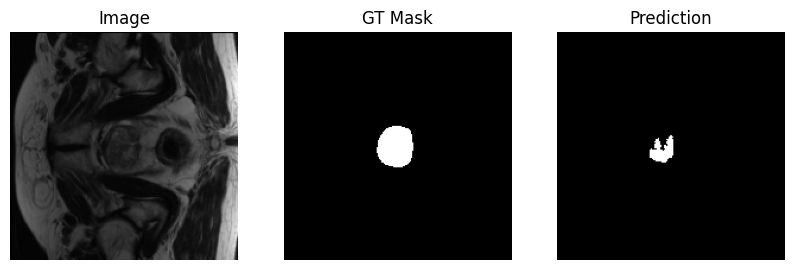

In [ ]:
img, gt = load_image_mask(val_files[0])
pred = model.predict(img[np.newaxis, ...])[0, ..., 0]

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img[...,0], cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("GT Mask")
plt.imshow(gt[...,0], cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred > 0.5, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
def segment_prostate(image, model, threshold=0.5):
    """
    image: numpy array (H, W)
    returns segmentation mask or null if empty
    """
    image = image.astype(np.float32)
    image = (image - image.min()) / (image.max() - image.min() + 1e-8)
    image = image[..., np.newaxis]

    pred = model.predict(image[np.newaxis, ...])[0, ..., 0]
    return (pred > threshold).astype(np.uint8)
